# Notebook 02 — Parameter Estimation (MLE + Beta Posterior)

**RESEARCH QUESTION**
| # | Research Question | Technique | Week |
|---|-------------------|-----------|------|
| RQ1 | Berapa probabilitas estimasi sebuah PR akan di-merge, dan seberapa tidak pasti estimasi tersebut? | MLE Bernoulli + Confidence Interval | W11–12 |
| RQ2 | Apakah rata-rata tingkat bug report berubah secara signifikan setelah rilis major terakhir (pandas 2.0)? | MLE Poisson + Z-test satu sampel | W11–13 |
| RQ3 | Berapa probabilitas bahwa sebuah issue yang dipilih secara acak membutuhkan lebih dari 30 hari untuk ditutup, diestimasi tanpa formula analitik? | Monte Carlo Simulation | W14 |

**Nama:** Kevindra Raditya Luthfiansyah

**Role:** Estimation Analyst

# AI Disclosure

**Member:** Kevindra Raditya Luthfiansyah — Estimation Analyst

**Tools used:** Claude (Anthropic) & GitHub Copilot — used only to suggest minor code improvements, refactorings, and logical revisions. The author performed all analysis, interpretation, and final write-up.

| Task                          | Tool                | Prompt summary                                   | Output modified?        |
| ----------------------------- | ------------------- | ------------------------------------------------ | ----------------------- |
| Generated API pagination loop | Claude              | "Paginate GitHub issues with rate limit handling" | Yes — added retry logic |
| Code review & logic revision  | Claude & Copilot    | "Suggest minor improvements and fix logic"     | Yes — minor revisions only |

**Written by author:** All interpretations, conclusions, and final decisions are the work of the author; AI tools were used only as assistants for code-level edits and suggestions.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.estimator import (mle_bernoulli, mle_poisson, beta_posterior, log_likelihood_bernoulli, log_likelihood_poisson)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 100
sns.set_theme(style="whitegrid", palette="muted")
print("Import berhasil")

Import berhasil


In [96]:
df_pr = pd.read_csv("../data/clean/pulls.csv",  parse_dates=["created_at","closed_at"])
df_iss = pd.read_csv("../data/clean/issues.csv", parse_dates=["created_at","closed_at"])

print(f"Pull Requests : {len(df_pr)} baris")
print(f"Issues        : {len(df_iss)} baris")
df_pr.head(3)

Pull Requests : 2500 baris
Issues        : 5650 baris


,id,type,state,created_at,closed_at,days_to_close,label_names,is_bug,is_merged,year_month,year
0,65716,pull_request,closed,2026-05-23 23:05:41+00:00,2026-05-24 04:28:42+00:00,0,NaN,0,0,2026-05,2026
1,65697,pull_request,closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,0,Index,0,1,2026-05,2026
2,65693,pull_request,closed,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,0,NaN,0,1,2026-05,2026


## MLE Bernoulli: PR Merge Rate

RQ1 — MLE Bernoulli: PR Merge Rate
Total PR           : 2500
PR di-merge (k)    : 1725
PR ditolak (n-k)   : 775
θ̂ (MLE)            : 0.6900
Artinya            : 69.00% PR kemungkinan di-merge


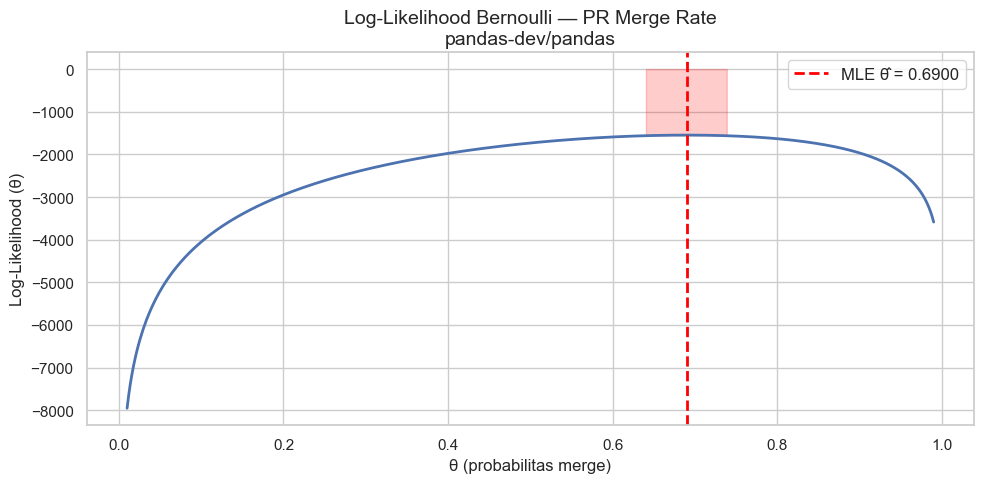

Puncak kurva = nilai MLE → titik yang paling 'masuk akal' sebagai estimasi θ


In [97]:
data_bernoulli = df_pr["is_merged"].values
result_mle = mle_bernoulli(data_bernoulli)

print("RQ1 — MLE Bernoulli: PR Merge Rate")
print(f"Total PR           : {result_mle['n']}")
print(f"PR di-merge (k)    : {result_mle['k']}")
print(f"PR ditolak (n-k)   : {result_mle['n'] - result_mle['k']}")
print(f"θ̂ (MLE)            : {result_mle['theta_hat']:.4f}")
print(f"Artinya            : {result_mle['theta_hat']*100:.2f}% PR kemungkinan di-merge")

k = result_mle["k"]
n = result_mle["n"]

theta_range = np.linspace(0.01, 0.99, 500)
ll_values = [log_likelihood_bernoulli(t, k, n) for t in theta_range]

plt.figure(figsize=(10, 5))
plt.plot(theta_range, ll_values, color="#4C72B0", linewidth=2)
plt.axvline(result_mle["theta_hat"], color="red", linestyle="--", linewidth=2,
            label=f"MLE θ̂ = {result_mle['theta_hat']:.4f}")
plt.fill_between(theta_range, ll_values,
                 where=[(t > result_mle["theta_hat"]-0.05 and
                         t < result_mle["theta_hat"]+0.05)
                        for t in theta_range],
                 alpha=0.2, color="red")
plt.title("Log-Likelihood Bernoulli — PR Merge Rate\npandas-dev/pandas", fontsize=14)
plt.xlabel("θ (probabilitas merge)")
plt.ylabel("Log-Likelihood (θ)")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
print("Puncak kurva = nilai MLE → titik yang paling 'masuk akal' sebagai estimasi θ")

Beta Posterior (Prior Seragam)
k (merged)  : 1725
m (ditolak) : 775
a = k+1     : 1726
β = m+1     : 776
Mode        : 0.6900
Mean        : 0.6898


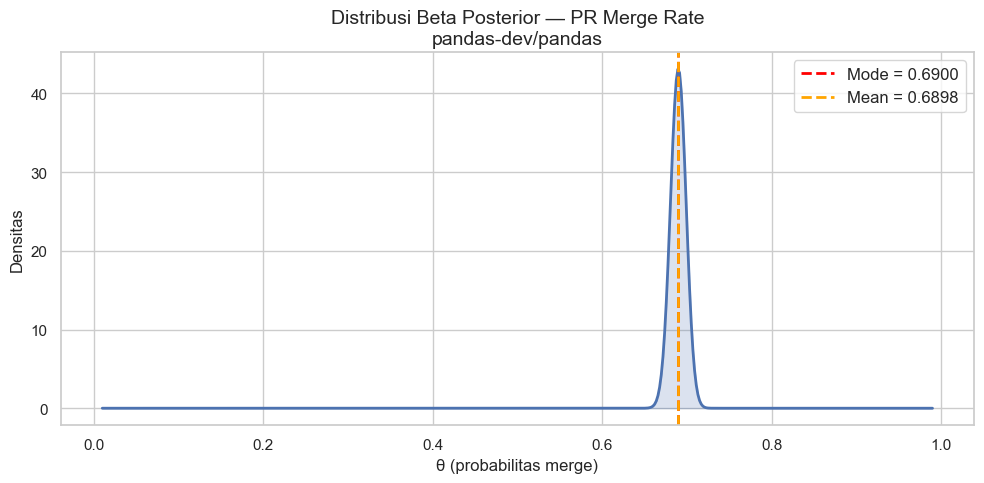

In [98]:
k = result_mle["k"]
m = result_mle["n"] - result_mle["k"]

result_beta = beta_posterior(k, m)

print("Beta Posterior (Prior Seragam)")
print(f"k (merged)  : {k}")
print(f"m (ditolak) : {m}")
print(f"a = k+1     : {result_beta['alpha']}")
print(f"β = m+1     : {result_beta['beta']}")
print(f"Mode        : {result_beta['mode']:.4f}")
print(f"Mean        : {result_beta['mean']:.4f}")

from scipy.stats import beta as beta_dist

theta_range = np.linspace(0.01, 0.99, 500)
pdf_values  = beta_dist.pdf(theta_range,
                            result_beta["alpha"],
                            result_beta["beta"])

plt.figure(figsize=(10, 5))
plt.plot(theta_range, pdf_values, color="#4C72B0", linewidth=2)
plt.axvline(result_beta["mode"], color="red", linestyle="--", linewidth=2,
            label=f"Mode = {result_beta['mode']:.4f}")
plt.axvline(result_beta["mean"], color="orange", linestyle="--", linewidth=2,
            label=f"Mean = {result_beta['mean']:.4f}")
plt.fill_between(theta_range, pdf_values, alpha=0.2, color="#4C72B0")
plt.title("Distribusi Beta Posterior — PR Merge Rate\npandas-dev/pandas", fontsize=14)
plt.xlabel("θ (probabilitas merge)")
plt.ylabel("Densitas")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Interpretasi — RQ1: Beta Posterior dan CI

RQ1 — Interpretasi: Beta Posterior dan CI — PR Merge Rate
θ̂ (MLE) : 0.6900 — dari 2500 PR, 1725 di-merge
Wald 95% CI           : [0.6719, 0.7081]
Clopper–Pearson 95% CI: [0.6715, 0.7081]


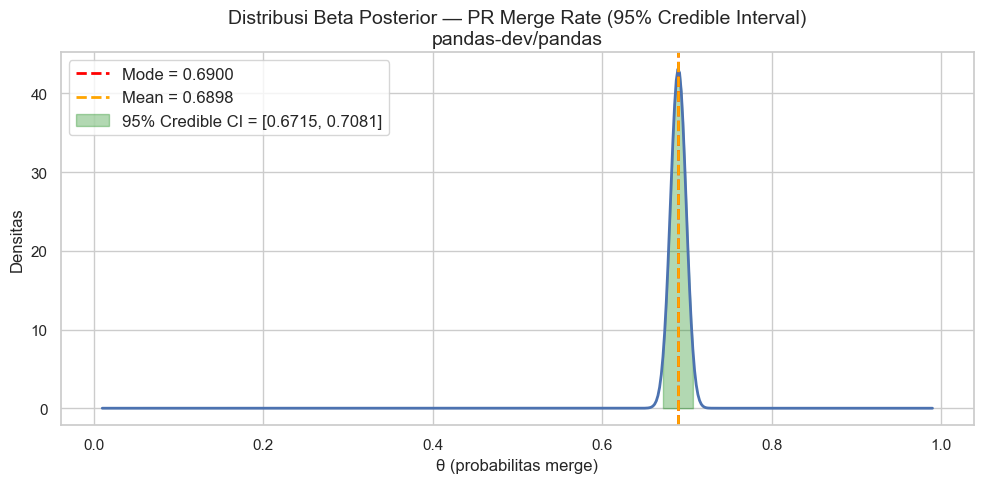

In [ ]:
theta_hat = result_mle['theta_hat']
k = result_mle['k']
n = result_mle['n']
from scipy.stats import beta as beta_dist, norm
import math
alpha = 0.05
se = math.sqrt(theta_hat*(1-theta_hat)/n)
z = norm.ppf(1-alpha/2)
wald_low = max(0, theta_hat - z*se)
wald_high = min(1, theta_hat + z*se)
if k == 0:
    cp_low = 0.0
else:
    cp_low = beta_dist.ppf(alpha/2, k, n-k+1)
if k == n:
    cp_high = 1.0
else:
    cp_high = beta_dist.ppf(1-alpha/2, k+1, n-k)
print("RQ1 — Interpretasi: Beta Posterior dan CI — PR Merge Rate")
print(f"θ̂ (MLE) : {theta_hat:.4f} — dari {n} PR, {k} di-merge")
print(f"Wald 95% CI           : [{wald_low:.4f}, {wald_high:.4f}]")
print(f"Clopper–Pearson 95% CI: [{cp_low:.4f}, {cp_high:.4f}]")

plt.figure(figsize=(10, 5))
plt.plot(theta_range, pdf_values, color="#4C72B0", linewidth=2)
plt.axvline(result_beta["mode"], color="red", linestyle="--", linewidth=2,
            label=f"Mode = {result_beta['mode']:.4f}")
plt.axvline(result_beta["mean"], color="orange", linestyle="--", linewidth=2,
            label=f"Mean = {result_beta['mean']:.4f}")
plt.fill_between(theta_range, pdf_values,
                 where=[(t > cp_low and t < cp_high) for t in theta_range],
                 alpha=0.3, color="green", label=f"95% Credible CI = [{cp_low:.4f}, {cp_high:.4f}]")
plt.title("Distribusi Beta Posterior — PR Merge Rate (95% Credible Interval)\npandas-dev/pandas", fontsize=14)
plt.xlabel("θ (probabilitas merge)")
plt.ylabel("Densitas")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Interpretasi — RQ2: MLE Poisson

RQ2 — MLE Poisson: Bug Report Rate
Total bulan diobservasi : 55
λ̂ (MLE)                 : 45.6727
Artinya                 : rata-rata 45.67 bug/bulan


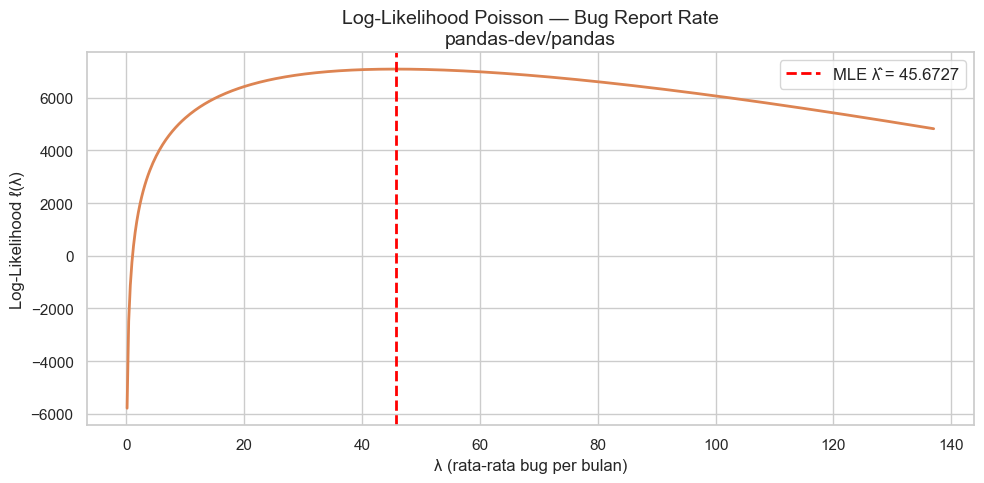

Puncak kurva = nilai MLE → estimasi terbaik rata-rata bug per bulan


In [ ]:
bug_monthly = df_iss.groupby("year_month")["is_bug"].sum().reset_index()
bug_monthly.columns = ["year_month", "bug_count"]
bug_data = bug_monthly["bug_count"].values

result_poisson = mle_poisson(bug_data)

print("RQ2 — MLE Poisson: Bug Report Rate")
print(f"Total bulan diobservasi : {result_poisson['n']}")
print(f"λ̂ (MLE)                 : {result_poisson['lambda_hat']:.4f}")
print(f"Artinya                 : rata-rata {result_poisson['lambda_hat']:.2f} bug/bulan")

lambda_range = np.linspace(0.1, result_poisson["lambda_hat"] * 3, 500)
ll_values = [log_likelihood_poisson(l, bug_data) for l in lambda_range]

plt.figure(figsize=(10, 5))
plt.plot(lambda_range, ll_values, color="#DD8452", linewidth=2)
plt.axvline(result_poisson["lambda_hat"], color="red", linestyle="--", linewidth=2,
            label=f"MLE λ̂ = {result_poisson['lambda_hat']:.4f}")
plt.title("Log-Likelihood Poisson — Bug Report Rate\npandas-dev/pandas", fontsize=14)
plt.xlabel("λ (rata-rata bug per bulan)")
plt.ylabel("Log-Likelihood ℓ(λ)")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
print("Puncak kurva = nilai MLE → estimasi terbaik rata-rata bug per bulan")

## Summary Estimation — Temuan Utama

| Variabel | Nilai | Digunakan di |
|----------|-------|--------------|
| θ̂ MLE Bernoulli (PR merge rate) | `theta_hat` dari `result_mle` | Notebook 03, 04 |
| 95% CI merge rate (Clopper–Pearson) | `[cp_low, cp_high]` | Notebook 03 |
| Beta Posterior mean merge rate | `result_beta['mean']` | Notebook 03 |
| λ̂ MLE Poisson (bug/bulan, keseluruhan) | `result_poisson['lambda_hat']` | Notebook 04 |

## Output untuk Layer Berikutnya / Role Berikutnya

**Member D (Hypothesis Testing):**
- `theta_hat` dari MLE Bernoulli → gunakan sebagai nilai H₀ untuk uji proporsi merge rate
- `result_poisson['lambda_hat']` → gunakan sebagai λ referensi untuk Z-test satu sampel
- Titik pemisah tetap **April 2023 (pandas 2.0)** — split data di `df_iss` pakai kolom `year_month`

**Member E (Simulation):**
- Distribusi Beta Posterior (`alpha`, `beta`) dari `result_beta` → prior untuk simulasi Bayesian
- `theta_hat` → seed probabilitas untuk simulasi Monte Carlo merge scenario